In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv("indian_gold_loan_data.csv")
df.head()


,Customer_ID,Name,Age,Occupation,Monthly_Income,Branch,Gold_Weight_g,Gold_Purity,Market_Value_INR,LTV_Ratio,Loan_Amount_INR,Tenure_Months,Past_Defaults,Default_Status
0,CUST-1000,Abeer Srivastava,61,Daily Wage,117863,Edappally,90.20,20,638661.10,73.526610,469585.86,12,2,0
1,CUST-1001,Samarth Purohit,27,Professional,113700,Edappally,25.55,22,198932.30,64.773032,128854.48,9,1,0
2,CUST-1002,Devansh Bajwa,48,Small Business,30414,Thrissur-Town,129.29,18,824223.75,62.495063,515099.15,12,2,1
3,CUST-1003,Advik Srinivas,29,Daily Wage,61654,Palakkad-Main,139.08,22,1082876.88,61.376661,664633.67,3,0,0
4,CUST-1004,Darpan Dey,55,Small Business,118093,Edappally,6.96,22,54190.56,85.428911,46294.41,24,3,1


In [5]:
print("======================================Data Details=======================Data Details========================\n")
print (f"Shape: {df.shape[0]} Rows X {df.shape[1]} Columns")
print(f"Dimensions: {df.ndim} D ")
print(f"Duplicate: {df.duplicated().sum()} ")
print(f"Missing Values: {df.isnull().sum().sum()} \n")
print("=============================================================================================\n")
print(df.info())


======================================Data Details=======================Data Details========================

Shape: 10000 Rows X 14 Columns
Dimensions: 2 D 
Duplicate: 0 
Missing Values: 0 


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       10000 non-null  str    
 1   Name              10000 non-null  str    
 2   Age               10000 non-null  int64  
 3   Occupation        10000 non-null  str    
 4   Monthly_Income    10000 non-null  int64  
 5   Branch            10000 non-null  str    
 6   Gold_Weight_g     10000 non-null  float64
 7   Gold_Purity       10000 non-null  int64  
 8   Market_Value_INR  10000 non-null  float64
 9   LTV_Ratio         10000 non-null  float64
 10  Loan_Amount_INR   10000 non-null  float64
 11  Tenure_Months     10000 non-null  int64  
 12  Past_Defaults     10000 non-null  int64  
 13 

# Statsitical Summary

In [6]:
df.describe()

,Age,Monthly_Income,Gold_Weight_g,Gold_Purity,Market_Value_INR,LTV_Ratio,Loan_Amount_INR,Tenure_Months,Past_Defaults,Default_Status
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.00000,10000.000000
mean,45.614400,82707.828100,101.546248,21.049000,7.566319e+05,75.053628,5.679186e+05,10.784100,1.51240,0.452700
std,14.425572,39087.290194,56.658313,2.221462,4.314417e+05,8.658351,3.323291e+05,7.267074,1.12293,0.497783
min,21.000000,15027.000000,5.000000,18.000000,3.187500e+04,60.003438,2.102418e+04,3.000000,0.00000,0.000000
25%,33.000000,48350.500000,51.865000,20.000000,3.800696e+05,67.537018,2.833324e+05,6.000000,1.00000,0.000000
50%,46.000000,83596.500000,100.950000,22.000000,7.438491e+05,75.121375,5.535350e+05,9.000000,2.00000,0.000000
75%,58.000000,116639.750000,150.055000,24.000000,1.115131e+06,82.576615,8.236058e+05,12.000000,3.00000,1.000000
max,70.000000,149981.000000,199.970000,24.000000,1.698555e+06,89.998730,1.517331e+06,24.000000,3.00000,1.000000


In [7]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'Occupation', 'Monthly_Income', 'Branch',
       'Gold_Weight_g', 'Gold_Purity', 'Market_Value_INR', 'LTV_Ratio',
       'Loan_Amount_INR', 'Tenure_Months', 'Past_Defaults', 'Default_Status'],
      dtype='str')

# Feature Engineering

### Droping Unwanted Features

In [8]:
df=df.drop(columns=["Customer_ID","Name","Branch"])
df

,Age,Occupation,Monthly_Income,Gold_Weight_g,Gold_Purity,Market_Value_INR,LTV_Ratio,Loan_Amount_INR,Tenure_Months,Past_Defaults,Default_Status
0,61,Daily Wage,117863,90.20,20,638661.10,73.526610,469585.86,12,2,0
1,27,Professional,113700,25.55,22,198932.30,64.773032,128854.48,9,1,0
2,48,Small Business,30414,129.29,18,824223.75,62.495063,515099.15,12,2,1
3,29,Daily Wage,61654,139.08,22,1082876.88,61.376661,664633.67,3,0,0
4,55,Small Business,118093,6.96,22,54190.56,85.428911,46294.41,24,3,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,21,Daily Wage,142994,69.19,22,538713.34,75.501611,406737.25,3,0,0
9996,35,Small Business,112793,134.92,20,955301.06,84.298838,805307.69,12,1,1
9997,46,Small Business,65917,190.29,20,1347348.34,77.773465,1047879.49,24,2,1
9998,26,Farmer,115230,44.66,22,347722.76,87.425668,303998.95,24,2,1


### Feature Extraction

In [9]:
occupation_map = {
    'Professional': 0.95,
    'Salaried': 0.85,
    'Small Business': 0.70,
    'Farmer': 0.60,
    'Daily Wage': 0.40
}
df['occ_score'] = df['Occupation'].map(occupation_map).fillna(0.55)
df["Debt_to_Income"]= df["Loan_Amount_INR"] / (df["Monthly_Income"]*12)
df

df

,Age,Occupation,Monthly_Income,Gold_Weight_g,Gold_Purity,Market_Value_INR,LTV_Ratio,Loan_Amount_INR,Tenure_Months,Past_Defaults,Default_Status,occ_score,Debt_to_Income
0,61,Daily Wage,117863,90.20,20,638661.10,73.526610,469585.86,12,2,0,0.40,0.332014
1,27,Professional,113700,25.55,22,198932.30,64.773032,128854.48,9,1,0,0.95,0.094440
2,48,Small Business,30414,129.29,18,824223.75,62.495063,515099.15,12,2,1,0.70,1.411354
3,29,Daily Wage,61654,139.08,22,1082876.88,61.376661,664633.67,3,0,0,0.40,0.898338
4,55,Small Business,118093,6.96,22,54190.56,85.428911,46294.41,24,3,1,0.70,0.032668
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,21,Daily Wage,142994,69.19,22,538713.34,75.501611,406737.25,3,0,0,0.40,0.237036
9996,35,Small Business,112793,134.92,20,955301.06,84.298838,805307.69,12,1,1,0.70,0.594975
9997,46,Small Business,65917,190.29,20,1347348.34,77.773465,1047879.49,24,2,1,0.70,1.324746
9998,26,Farmer,115230,44.66,22,347722.76,87.425668,303998.95,24,2,1,0.60,0.219849


# Model Training

In [10]:
from sklearn.model_selection import train_test_split  
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [11]:
x=df.drop(columns=["Default_Status","Occupation"])
y=df["Default_Status"]
x_train,y_test,x_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [12]:
print("Features used:", x.columns.tolist())
print("Target distribution:")
print(y.value_counts(normalize=True))  # CHECK IMBALANCE HERE

Features used: ['Age', 'Monthly_Income', 'Gold_Weight_g', 'Gold_Purity', 'Market_Value_INR', 'LTV_Ratio', 'Loan_Amount_INR', 'Tenure_Months', 'Past_Defaults', 'occ_score', 'Debt_to_Income']
Target distribution:
Default_Status
0    0.5473
1    0.4527
Name: proportion, dtype: float64


# Random Forest Model 

In [13]:
# Correct the train_test_split assignment
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest Classifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(x_train, y_train)

# Make predictions
y_pred = model_rf.predict(x_test)

# Print results
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9086666666666666

Confusion Matrix:
[[1504  138]
 [ 136 1222]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1642
           1       0.90      0.90      0.90      1358

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



In [14]:
# Example input for a non-default scenario
sample_non_default = {
    'Age': 35,
    'Monthly_Income': 120000,
    'Gold_Weight_g': 50,
    'Gold_Purity': 22,
    'Market_Value_INR': 400000,
    'LTV_Ratio': 75,
    'Loan_Amount_INR': 300000,
    'Tenure_Months': 12,
    'Past_Defaults': 0,
    'occ_score': 0.85,  # e.g., 'Salaried'
    'Debt_to_Income': 0.25
}

# Example input for a default scenario
sample_default = {
    'Age': 45,
    'Monthly_Income': 30000,
    'Gold_Weight_g': 100,
    'Gold_Purity': 18,
    'Market_Value_INR': 600000,
    'LTV_Ratio': 85,
    'Loan_Amount_INR': 510000,
    'Tenure_Months': 24,
    'Past_Defaults': 3,
    'occ_score': 0.40,  # e.g., 'Daily Wage'
    'Debt_to_Income': 1.42
}

# Convert to DataFrame
input_df = pd.DataFrame([sample_non_default, sample_default])

# Predict
predictions = model_rf.predict(input_df)
print("Predictions (0 = Non-default, 1 = Default):", predictions)

Predictions (0 = Non-default, 1 = Default): [0 1]


# XG Boost Classifier

In [15]:
from xgboost import XGBClassifier

# Train XGBoost Classifier

model_xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(x_train, y_train)

# Make predictions
y_pred_xgb = model_xgb.predict(x_test)

# Print results
print("XGBoost Accuracy Score:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

C:\Users\user'\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [10:46:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy Score: 0.901

XGBoost Confusion Matrix:
[[1493  149]
 [ 148 1210]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1642
           1       0.89      0.89      0.89      1358

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



In [16]:
# Example input for a non-default scenario
sample_non_default = {
    'Age': 35,
    'Monthly_Income': 120,
    'Gold_Weight_g': 50,
    'Gold_Purity': 22,
    'Market_Value_INR': 400000,
    'LTV_Ratio': 75,
    'Loan_Amount_INR': 300000000,
    'Tenure_Months': 12,
    'Past_Defaults': 0,
    'occ_score': 0.85,  # e.g., 'Salaried'
    'Debt_to_Income': 0.25
}

# Example input for a default scenario
sample_default = {
    'Age': 45,
    'Monthly_Income': 30000,
    'Gold_Weight_g': 100,
    'Gold_Purity': 18,
    'Market_Value_INR': 600000,
    'LTV_Ratio': 85,
    'Loan_Amount_INR': 510000,
    'Tenure_Months': 24,
    'Past_Defaults': 3,
    'occ_score': 0.40,  # e.g., 'Daily Wage'
    'Debt_to_Income': 1.42
}

# Convert to DataFrame
input_xgb = pd.DataFrame([sample_non_default, sample_default])

# Predict
predictions_xgb = model_xgb.predict(input_xgb)
print("Predictions (0 = Non-default, 1 = Default):", predictions_xgb)

Predictions (0 = Non-default, 1 = Default): [0 1]


# Model Comparison 

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Compare metrics for Random Forest and XGBoost


# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_conf_matrix = confusion_matrix(y_test, y_pred)
rf_report = classification_report(y_test, y_pred, output_dict=True)

# XGBoost metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_conf_matrix = confusion_matrix(y_test, y_pred_xgb)
xgb_report = classification_report(y_test, y_pred_xgb, output_dict=True)

# Display comparison
print("=== Random Forest Classifier ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print("Confusion Matrix:\n", rf_conf_matrix)
print("Classification Report:\n", classification_report(y_test, y_pred))

print("\n=== XGBoost Classifier ===")
print(f"Accuracy: {xgb_accuracy:.4f}")
print("Confusion Matrix:\n", xgb_conf_matrix)
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

# Optional: Create a summary DataFrame for easier comparison

metrics = ['precision', 'recall', 'f1-score', 'support']
labels = ['0', '1', 'accuracy', 'macro avg', 'weighted avg']

summary = pd.DataFrame({
    'Random Forest': [rf_report[label][metric] if label != 'accuracy' else rf_report['accuracy'] for label in labels for metric in (metrics if label != 'accuracy' else ['accuracy'])],
    'XGBoost': [xgb_report[label][metric] if label != 'accuracy' else xgb_report['accuracy'] for label in labels for metric in (metrics if label != 'accuracy' else ['accuracy'])]
}, index=[f"{label} {metric}" if label != 'accuracy' else 'accuracy' for label in labels for metric in (metrics if label != 'accuracy' else ['accuracy'])])

print("\n=== Metrics Comparison Table ===")
display(summary)

=== Random Forest Classifier ===
Accuracy: 0.9087
Confusion Matrix:
 [[1504  138]
 [ 136 1222]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      1642
           1       0.90      0.90      0.90      1358

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000


=== XGBoost Classifier ===
Accuracy: 0.9010
Confusion Matrix:
 [[1493  149]
 [ 148 1210]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      1642
           1       0.89      0.89      0.89      1358

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000


=== Metrics Comparison Table ===


,Random Forest,XGBoost
0 precision,0.917073,0.909811
0 recall,0.915956,0.909257
0 f1-score,0.916514,0.909534
0 support,1642.000000,1642.000000
1 precision,0.898529,0.890361
1 recall,0.899853,0.891016
1 f1-score,0.899191,0.890688
1 support,1358.000000,1358.000000
accuracy,0.908667,0.901000
macro avg precision,0.907801,0.900086


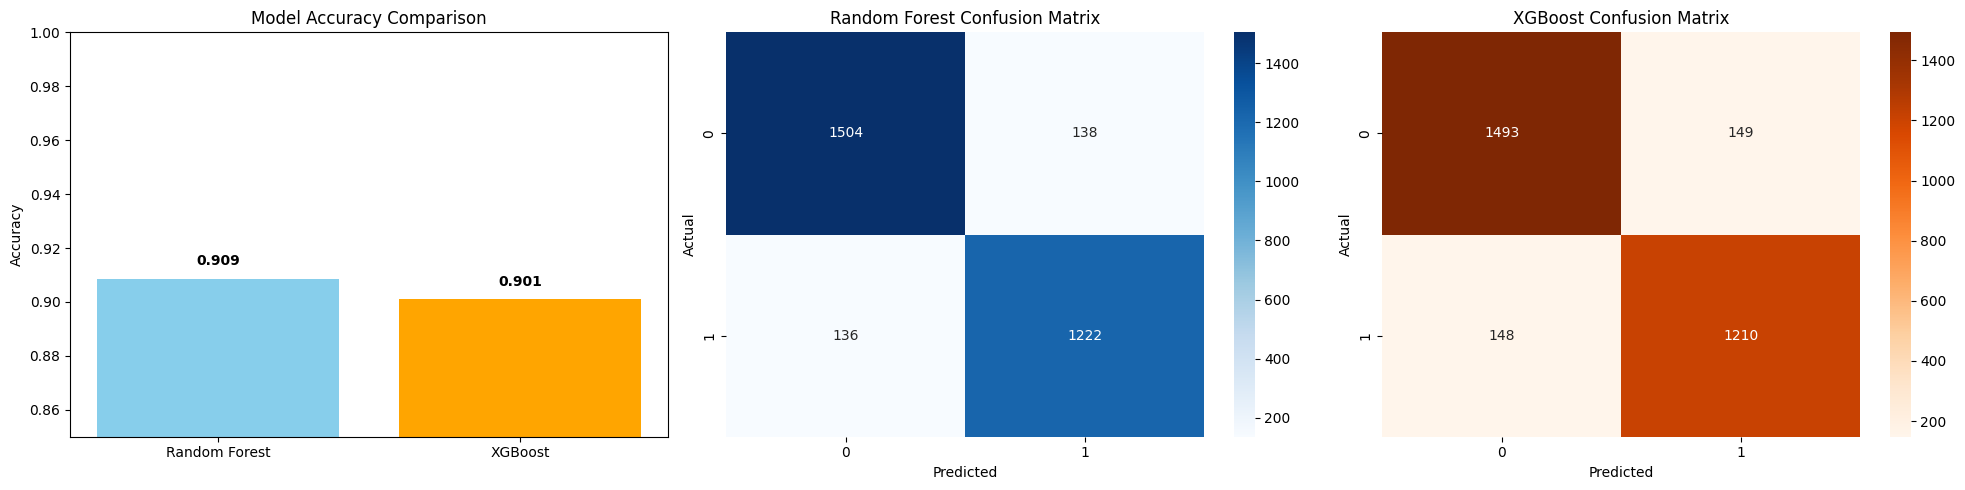

In [18]:
# Visualize model comparison and confusion matrices

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Accuracy Bar Plot
axes[0].bar(['Random Forest', 'XGBoost'], [rf_accuracy, xgb_accuracy], color=['skyblue', 'orange'])
axes[0].set_ylim(0.85, 1)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
for i, v in enumerate([rf_accuracy, xgb_accuracy]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha='center', fontweight='bold')

# 2. Confusion Matrix - Random Forest
sns.heatmap(rf_conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. Confusion Matrix - XGBoost
sns.heatmap(xgb_conf_matrix, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('XGBoost Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Credit Score Calculation

In [19]:
# Credit Risk Score Calculation (Rule-Based Method)

def calculate_credit_score(age, monthly_income, gold_weight_g, gold_purity, 
                          market_value_inr, ltv_ratio, loan_amount_inr, 
                          tenure_months, past_defaults, occ_score, debt_to_income):
    """
    Calculate credit risk score (1-100) using rule-based formula.
    Higher score = Lower risk
    """
    # Normalize inputs
    D = min(past_defaults / 5, 1)
    DTI = min(debt_to_income / 2, 1)
    LTV = ltv_ratio / 100
    INC = min(monthly_income / 100000, 1)
    OCC = occ_score
    
    # Calculate risk factor
    risk_factor = 0.30 * D + 0.25 * DTI + 0.20 * LTV - 0.15 * INC - 0.10 * OCC
    
    # Convert to 1-100 score
    score = round(100 * (1 - risk_factor))
    
    # Clamp to [1, 100]
    score = max(1, min(100, score))
    
    return score

# Test Case 1: Low-Risk Profile
low_risk_score = calculate_credit_score(
    age=50, monthly_income=100000, gold_weight_g=100, gold_purity=24,
    market_value_inr=900000, ltv_ratio=40, loan_amount_inr=3600,
    tenure_months=24, past_defaults=0, occ_score=0.9, debt_to_income=0.2
)

# Test Case 2: High-Risk Profile
high_risk_score = calculate_credit_score(
    age=25, monthly_income=500, gold_weight_g=12, gold_purity=24,
    market_value_inr=14500, ltv_ratio=95, loan_amount_inr=1500000000,
    tenure_months=12, past_defaults=5, occ_score=0.2, debt_to_income=2.0
)

# Display Results
print("="*70)
print("CREDIT RISK SCORE CALCULATION (RULE-BASED)")
print("="*70)
print(f"\n LOW-RISK CASE:")
print(f"   Past Defaults: 0 | DTI: 0.2 | LTV: 40% | Income: ₹100,000 | Occ Score: 0.9")
print(f"   → Credit Score: {low_risk_score}/100 ✓ (Lower Risk)")

print(f"\n HIGH-RISK CASE:")
print(f"   Past Defaults: 5 | DTI: 2.0 | LTV: 95% | Income: ₹10,000 | Occ Score: 0.2")
print(f"   → Credit Score: {high_risk_score}/100  (Higher Risk)")

print(f"\n Score Difference: {low_risk_score - high_risk_score} points")
print("="*70)

CREDIT RISK SCORE CALCULATION (RULE-BASED)

 LOW-RISK CASE:
   Past Defaults: 0 | DTI: 0.2 | LTV: 40% | Income: ₹100,000 | Occ Score: 0.9
   → Credit Score: 100/100 ✓ (Lower Risk)

 HIGH-RISK CASE:
   Past Defaults: 5 | DTI: 2.0 | LTV: 95% | Income: ₹10,000 | Occ Score: 0.2
   → Credit Score: 28/100  (Higher Risk)

 Score Difference: 72 points


# Model Saving

In [20]:
import joblib
joblib.dump(model_rf, 'Loan_credit_model.pkl')
print("Random Forest model saved as 'Loan_credit_model.pkl'")

Random Forest model saved as 'Loan_credit_model.pkl'
